# Diagnosis of assigned observation errors in MET Norway's coastal forecasting system

This notebook demonstrates how the diagnosis of observation errors, as proposed by Desrozier et al. (2005), can be applied to the output from the ROMS 4D-var system. The results do not necessarily yield the "correct" observation errors, but an estimate which can be used to tune the system. Repeating the diagnosis after changing the observation error will yield different estimates. The process of finding optimized observational error is thus an iterative process, which should be carried out on regular intervals.  

Desroziers, G., Berre, L., Chapnik, B. and Poli, P. (2005), Diagnosis of observation, background and analysis-error statistics in observation space. Q.J.R. Meteorol. Soc., 131: 3385-3396. https://doi.org/10.1256/qj.05.108

In [1]:
import datetime 
import numpy as np
import sys, os
import pyromsobs
import pickle 
import matplotlib.pyplot as plt
from IPython.utils import io

# generic path to Norkyst DA 4D-var outputfile on MET Norway's thredds server:
modfile = 'https://thredds.met.no/thredds/dodsC/sea_norshelf_obs_files/{0}/norshelf_mod_{1}T00Z.nc'

# syntax for accessing a file for a given day:
# day = datetime.datetime(2025,5,25)
# print(modfile.format(day.strftime("%Y/%m"), day.strftime("%Y%m%d")

'''
The last couple of cells in this notebook contains various functions to help with 
different aspects of the processing. By running the code in this cell, the cells corresponding
to the indices in the "run_cell" command are executed and thus made available for use in the notebook.
'''

from IPython.display import Javascript, display
def run_cell(cell_index):
    for i in cell_index:
        display(Javascript(f'Jupyter.notebook.execute_cells([{i}])'))

run_cell([-2, -1]) # Executes the cells with corresponding indices

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Observation provenance

To perform the diagnosis on different sets of observational sources, we will make use of the assigned provenance of the observations. 
All observation sources are assigned a 7 digit provenance: 

- digit 1 indicates observation type, (2 for radial current, 6 for temperature, 7 for salinity) 
- digit 2-3 indicates different observational platforms (e.g. CODAR HF antenna, CTD, ADCP, Argo etc.)
- digit 4-5 indicates the provider (CMEMS, PODAAC, MET Norway) 
- digit 6-7 indicates the specific station/ship/satellite etc. (e.g. Sentinel-3A, a specific HF radar location) 


##  Calculate observation error statistics for the Norwegian HF radar network: 

Along the Norwegian coast there are currently 6 operational HF radar antennas. Our coastal forecasting system assimilates the radial currents from all six sites, and we will diagnose each antenna seperately.


In [28]:
# The HF radar network:
HF_antennas = {"2010101" : 'Torungen', 
               "2010102": "Fruholmen", 
               "2010103": "Berlevåg", 
               "2010104": "Jomfruland", 
               "2010105": "Fedje", 
               "2010106": "Slåtterøy"}

firstday = datetime.datetime(2025,1,1)
lastday = datetime.datetime.now() - datetime.timedelta(days = 1)

# Call the function that performs the diagnosis:
internal_error_estimates_hf, error_estimates_hf = Desroziers(modfile, firstday, lastday, list(HF_antennas.keys()), combine=False )
count = 0


    




Provenance                    	Nobs      	B_given   	B_estimate	R_given   	R_estimate


2010101                       	7189      	0.063375  	0.009293  	0.021211  	0.009455  
2010101                       	8528      	0.061002  	0.012105  	0.023839  	0.009148  
2010101                       	8285      	0.055467  	0.007735  	0.020865  	0.006914  
2010101                       	6544      	0.057827  	0.009645  	0.016881  	0.009154  
2010101                       	4318      	0.066838  	0.008156  	0.017465  	0.007146  
2010101                       	2439      	0.077348  	0.005953  	0.017733  	0.006643  
2010101                       	3926      	0.078167  	0.009156  	0.021969  	0.010559  
2010101                       	6359      	0.080630  	0.013270  	0.026995  	0.020792  
2010101                       	5824      	0.085034  	0.015308  	0.027247  	0.018563  
2010101                       	4208      	0.082493  	0.015094  	0.027282  	0.016740  
2010101                       	7153      	0.068540

2010101                       	6425      	0.080491  	0.020948  	0.021491  	0.015526  
2010101                       	3806      	0.099688  	0.010109  	0.023260  	0.011986  

Unable to read modfile for 2025-04-10 00:00:00, skipping....

2010101                       	6689      	0.084200  	0.023708  	0.022655  	0.019360  
2010101                       	9961      	0.072196  	0.009650  	0.021516  	0.011981  
2010101                       	9160      	0.071203  	0.009876  	0.019967  	0.011343  
2010101                       	9265      	0.072577  	0.014549  	0.022727  	0.014978  
2010101                       	8579      	0.073560  	0.009632  	0.021924  	0.011942  
2010101                       	8946      	0.074685  	0.009191  	0.019620  	0.009931  
2010101                       	12863     	0.062275  	0.010090  	0.020783  	0.009708  
2010101                       	7749      	0.045919  	0.004966  	0.022939  	0.007481  
2010101                       	2083      	0.069687  	0.008526  	0.026445  	0.

2010102                       	6841      	0.041857  	0.007188  	0.038070  	0.020762  
2010102                       	11055     	0.043074  	0.007223  	0.039762  	0.025748  
2010102                       	8539      	0.043949  	0.005083  	0.044221  	0.023462  
2010102                       	3087      	0.047401  	0.006312  	0.034570  	0.018228  
2010102                       	8413      	0.044696  	0.007622  	0.039124  	0.022832  
2010102                       	16620     	0.045691  	0.009433  	0.042643  	0.022901  
2010102                       	17358     	0.045049  	0.011736  	0.044460  	0.026135  
2010102                       	26003     	0.042480  	0.010063  	0.044925  	0.024694  
2010102                       	21990     	0.043892  	0.008994  	0.046615  	0.026621  
2010102                       	20587     	0.045179  	0.012627  	0.050545  	0.033828  
2010102                       	26893     	0.043076  	0.011021  	0.051709  	0.032269  
2010102                       	28260     	0.042734  	0

2010102                       	17333     	0.041377  	0.003348  	0.029226  	0.012623  
2010102                       	15747     	0.041474  	0.003862  	0.027947  	0.012682  
2010102                       	20664     	0.039051  	0.005593  	0.028667  	0.012725  
2010102                       	27475     	0.039478  	0.003985  	0.034486  	0.015870  
2010102                       	9970      	0.047974  	0.002886  	0.044666  	0.021386  
2010102                       	22209     	0.045305  	0.006996  	0.044791  	0.023943  
2010102                       	19935     	0.045536  	0.003806  	0.046680  	0.026364  
2010102                       	21563     	0.043543  	0.004016  	0.044625  	0.021553  
2010102                       	22573     	0.043962  	0.004684  	0.044299  	0.021578  
2010102                       	29485     	0.041470  	0.004850  	0.042530  	0.020461  
2010102                       	44175     	0.036625  	0.005201  	0.038883  	0.016043  
2010103                       	8687      	0.073793  	0

2010103                       	3065      	0.051325  	0.004821  	0.037169  	0.036208  
2010103                       	9560      	0.050229  	0.010625  	0.036798  	0.026460  
2010103                       	9732      	0.049425  	0.005974  	0.031477  	0.018791  
2010103                       	9230      	0.049213  	0.004343  	0.029659  	0.016210  
2010103                       	6379      	0.050659  	0.001945  	0.030781  	0.016557  
2010103                       	4778      	0.050419  	0.003116  	0.029848  	0.016378  
2010103                       	5900      	0.050623  	0.003599  	0.033483  	0.025788  

Unable to read modfile for 2025-04-10 00:00:00, skipping....

2010103                       	7446      	0.049679  	0.010143  	0.042449  	0.029235  
2010103                       	1426      	0.047995  	0.005747  	0.034897  	0.031045  
2010103                       	2634      	0.054571  	0.005101  	0.040814  	0.044360  
2010103                       	4661      	0.056346  	0.008543  	0.042981  	0.

2010104                       	196       	0.082666  	0.021289  	0.025504  	0.012184  
2010104                       	395       	0.080352  	0.014958  	0.036830  	0.016774  
2010104                       	634       	0.071725  	0.011418  	0.050789  	0.020620  
2010104                       	612       	0.070985  	0.011171  	0.051686  	0.024657  
2010104                       	618       	0.070410  	0.013530  	0.050987  	0.049430  
2010104                       	812       	0.066693  	0.016729  	0.060568  	0.058981  
2010104                       	766       	0.068861  	0.010993  	0.063450  	0.050190  
2010104                       	283       	0.097800  	0.022855  	0.038462  	0.053621  
2010104                       	113       	0.099246  	0.033097  	0.041986  	0.047884  
2010104                       	16        	0.105643  	0.000150  	0.062363  	0.026644  
2010104                       	551       	0.083491  	-0.000203 	0.044603  	0.084618  
2010104                       	650       	0.069051  	0

2010105                       	31311     	0.046433  	0.008257  	0.036079  	0.015994  
2010105                       	38645     	0.043704  	0.006560  	0.036169  	0.013207  
2010105                       	40568     	0.041650  	0.005255  	0.035150  	0.011764  
2010105                       	39918     	0.040857  	0.003450  	0.037867  	0.012059  
2010105                       	37705     	0.040364  	0.003465  	0.035175  	0.010534  
2010105                       	32981     	0.041052  	0.003799  	0.031719  	0.009748  
2010105                       	30028     	0.042117  	0.007753  	0.032791  	0.013892  

Unable to read modfile for 2025-01-14 00:00:00, skipping....


Unable to read modfile for 2025-01-15 00:00:00, skipping....


Unable to read modfile for 2025-01-16 00:00:00, skipping....


Unable to read modfile for 2025-01-17 00:00:00, skipping....


Unable to read modfile for 2025-01-18 00:00:00, skipping....


Unable to read modfile for 2025-01-19 00:00:00, skipping....


Unable to read modf

2010105                       	31143     	0.029103  	0.004635  	0.029316  	0.012508  
2010105                       	31452     	0.029608  	0.003970  	0.032473  	0.013920  
2010105                       	32647     	0.029626  	0.004121  	0.036701  	0.014119  
2010105                       	32576     	0.029066  	0.005811  	0.036097  	0.014269  
2010105                       	30104     	0.029335  	0.004155  	0.036570  	0.014252  
2010105                       	30862     	0.029501  	0.004728  	0.037618  	0.014821  
2010105                       	29050     	0.030149  	0.004429  	0.034817  	0.013562  
2010105                       	28790     	0.030293  	0.003420  	0.029359  	0.008298  
2010105                       	30037     	0.030420  	0.002820  	0.029455  	0.007849  
2010105                       	30019     	0.030530  	0.004088  	0.030721  	0.009826  
2010105                       	26573     	0.031163  	0.004132  	0.031749  	0.012945  
2010105                       	21688     	0.031397  	0

2010106                       	26519     	0.046605  	0.007014  	0.046854  	0.025572  
2010106                       	32820     	0.043581  	0.007380  	0.047445  	0.030461  
2010106                       	33541     	0.043475  	0.009564  	0.049497  	0.029390  
2010106                       	32633     	0.043645  	0.009416  	0.047928  	0.025417  
2010106                       	31737     	0.043507  	0.009878  	0.048410  	0.025000  
2010106                       	32829     	0.043019  	0.006980  	0.049160  	0.025656  
2010106                       	33680     	0.042245  	0.005756  	0.050898  	0.024601  
2010106                       	31367     	0.043050  	0.007285  	0.051793  	0.024761  
2010106                       	29492     	0.042968  	0.008018  	0.049822  	0.024952  
2010106                       	31027     	0.040000  	0.007122  	0.048538  	0.022336  
2010106                       	33087     	0.039122  	-0.000181 	0.049671  	0.032118  
2010106                       	31090     	0.039420  	0

2010106                       	32008     	0.029857  	0.004183  	0.028656  	0.011742  
2010106                       	35632     	0.029502  	0.004344  	0.030853  	0.012875  
2010106                       	31490     	0.030557  	0.003291  	0.030713  	0.011438  
2010106                       	31049     	0.030604  	0.003412  	0.027389  	0.010673  


Provenance                    	Nobs      	B_given   	B_estimate	R_given   	R_estimate


2010101                       	1011989   	0.067672  	0.010380  	0.022298  	0.013816  
2010102                       	2064681   	0.042832  	0.006879  	0.044737  	0.025883  
2010103                       	789924    	0.054225  	0.006979  	0.035879  	0.025574  
2010104                       	89930     	0.085993  	0.012877  	0.045323  	0.026161  
2010105                       	4259917   	0.036446  	0.005807  	0.043447  	0.021499  
2010106                       	3654999   	0.038094  	0.005673  	0.036278  	0.018466  


### Let's have a look at the results! 

In the figure below we plot time series of the assigned observation errors (**R_given**) and the estimated observation errors (**R_estimate**), as well as their average values over the period evaluated.  

We can see that the assigned observation error is higher than the estimated error most of the time, but on a few occations the lines intercept. Thus, it might be reasonable to adjust the observation error down somewhat. This adjustment would lead to an increased impact of the HF observations, as a lower observational error indicates higher trust in the quality of the observations.

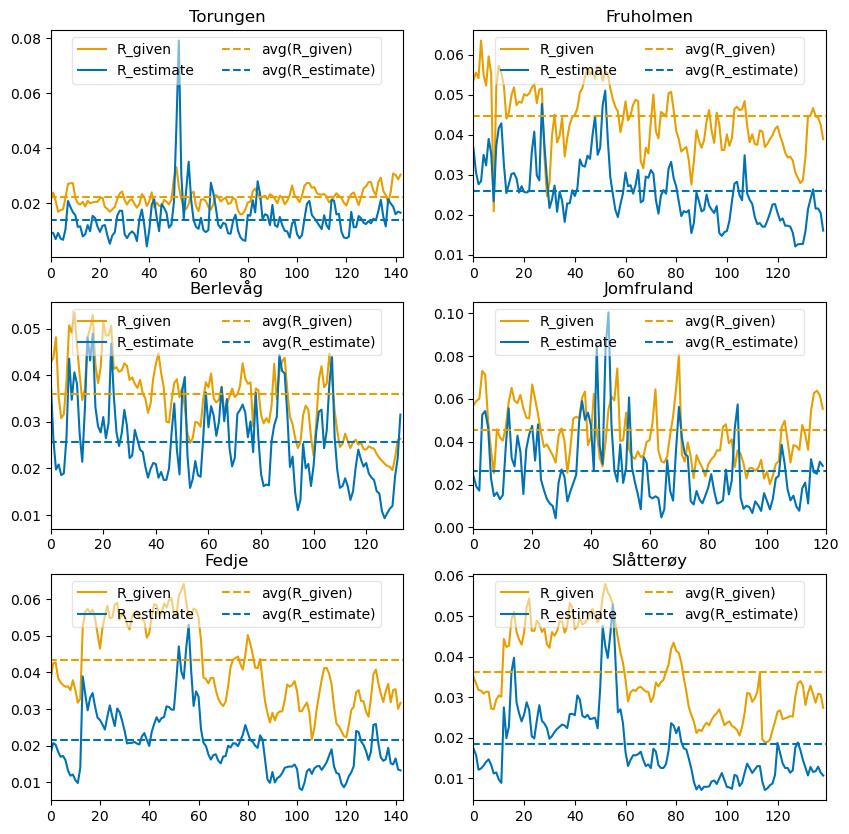

In [29]:

fig, axes = plt.subplots(nrows = 3, ncols =2, figsize = (10,10) )
axes = axes.ravel()
count = 0
for key in internal_error_estimates_hf.keys():
    axes[count].plot(internal_error_estimates_hf[key]['Ravg'], label = 'R_given',  color = '#E69F00')
    axes[count].plot(internal_error_estimates_hf[key]['REstimateavg'], label = 'R_estimate' , color = '#0072B2')
    
    axes[count].hlines(error_estimates_hf[key]['Ravg'],-5, len(internal_error_estimates_hf[key]['Ravg'])+5, label = 'avg(R_given)',  color = '#E69F00', linestyle = 'dashed')
    axes[count].hlines(error_estimates_hf[key]['REstimateavg'],  -5, len(internal_error_estimates_hf[key]['Ravg'])+5,label = 'avg(R_estimate)', color = '#0072B2', linestyle = 'dashed')
    
    axes[count].set_title(HF_antennas[key])
    axes[count].legend(loc = 'upper center', ncols =2, framealpha = 0.5)
    axes[count].set_xlim([0,len(internal_error_estimates_hf[key]['Ravg'])])
    count += 1

## Calculate observation error statistics for Institue of Marine Research's network of coastal hydrography stations

The institute of Marine Research (IMR) has 8 coastal hydrography stations (see [here](https://www.imr.no/forskning/forskningsdata/stasjoner/index.html)). At these locations, CTD profiles of temperature and salinity are taken at intervals of 2-4 weeks with the help of local fishermen. The observations are transferred to MET Norway as soon as they've been uploaded to IMR. 
As there are quite few observations, we will perform the diagnosis jointly for all stations. This is achieved by passing the argument "combine = True" to the Desrozier function. 


In [12]:
# A dictionary of the relevant provenances for the stations. 
# Note that these are the temperature observations - indicated by the 1. digit. 
# The provenances of the salinity observations from these stations can be attained by simply changing
# the first digit from "6" to "7". 

IMR_coastal_hydrography ={ "6001101" : "lista", 
                           "6001102": "YtreUtsira",
                           "6001122": "IndreUtsira",
                           "6001103": "sognesjøen",
                           "6001104": "bud",
                           "6001180": "skrova",
                           "6001107": "eggum",
                           "6001108": "ingøy"} 

firstday = datetime.datetime(2025,1,1)
lastday = datetime.datetime.now() - datetime.timedelta(days = 1)

# Perform the diagnosis for temperature:
internal_error_estimates_temp, error_estimates_temp = Desroziers(modfile, firstday, lastday, list(IMR_coastal_hydrography.keys()), combine = True )

# Create a dictionary with the corresponding salinity provenances, and carry out the analysis:
IMR_coastal_hydrography_salt =  {}
for key in IMR_coastal_hydrography.keys():
    IMR_coastal_hydrography_salt[key.replace('600', '700')] = IMR_coastal_hydrography[key]

internal_error_estimates_salt, error_estimates_salt = Desroziers(modfile, firstday, lastday, list(IMR_coastal_hydrography_salt.keys()), combine = True )




Provenance                    	Nobs      	B_given   	B_estimate	R_given   	R_estimate


[6001101, 6001102, 6001122, 6001103, 6001104, 6001180, 6001107, 6001108]	80        	0.654640  	0.534647  	0.257400  	0.169677  
[6001101, 6001102, 6001122, 6001103, 6001104, 6001180, 6001107, 6001108]	40        	0.312623  	0.011219  	0.258015  	0.024488  
[6001101, 6001102, 6001122, 6001103, 6001104, 6001180, 6001107, 6001108]	40        	0.761261  	0.259608  	0.263957  	0.452867  
[6001101, 6001102, 6001122, 6001103, 6001104, 6001180, 6001107, 6001108]	80        	1.021378  	0.347038  	0.262891  	1.256827  

Unable to read modfile for 2025-01-14 00:00:00, skipping....


Unable to read modfile for 2025-01-15 00:00:00, skipping....


Unable to read modfile for 2025-01-16 00:00:00, skipping....


Unable to read modfile for 2025-01-17 00:00:00, skipping....


Unable to read modfile for 2025-01-18 00:00:00, skipping....


Unable to read modfile for 2025-01-19 00:00:00, skipping....


Unable to read modf

[7001101, 7001102, 7001122, 7001103, 7001104, 7001180, 7001107, 7001108]	40        	0.040000  	0.014876  	0.043492  	0.023675  
[7001101, 7001102, 7001122, 7001103, 7001104, 7001180, 7001107, 7001108]	80        	0.040000  	-0.000064 	0.045822  	0.100405  
[7001101, 7001102, 7001122, 7001103, 7001104, 7001180, 7001107, 7001108]	40        	0.040000  	-0.000008 	0.048152  	0.178307  
[7001101, 7001102, 7001122, 7001103, 7001104, 7001180, 7001107, 7001108]	40        	0.039568  	0.040958  	0.049534  	0.183432  
[7001101, 7001102, 7001122, 7001103, 7001104, 7001180, 7001107, 7001108]	40        	0.039561  	0.025567  	0.049534  	0.125165  
[7001101, 7001102, 7001122, 7001103, 7001104, 7001180, 7001107, 7001108]	40        	0.040000  	0.029468  	0.043700  	0.041076  
[7001101, 7001102, 7001122, 7001103, 7001104, 7001180, 7001107, 7001108]	40        	0.040000  	0.012217  	0.043700  	0.012050  
[7001101, 7001102, 7001122, 7001103, 7001104, 7001180, 7001107, 7001108]	40        	0.039654  	0.011837 

### Let's have a look at the results! 

As for the case of HF radar, we plot time series of the assigned observation errors (**R_given**) and the estimated observation errors (**R_estimate**), as well as their average values over the period evaluated, for temperature and salinity.   

The results show that for the coastal hydrography profiles, the assigned observational errors are lower than the estimates from the Dezrosier error diagnosis, meaning that it would be a good idea to revisit how these error are set, and increase them to avoid giving them too much weight in the 4D-Var analysis. 

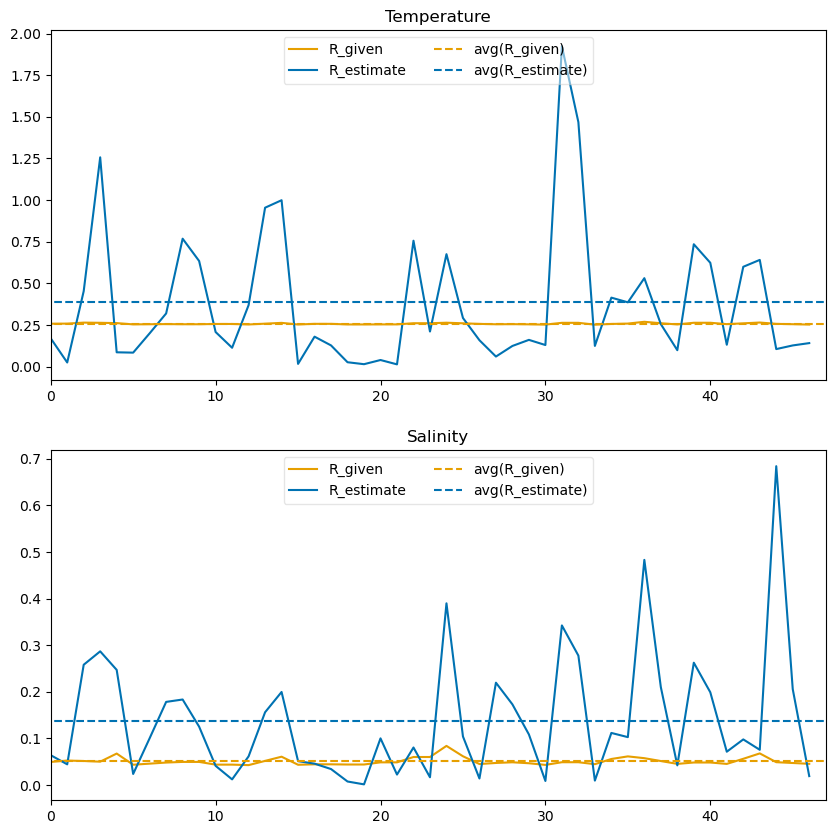

In [13]:

fig, axes = plt.subplots(nrows = 2, ncols =1, figsize = (10,10) )
axes = axes.ravel()
count = 0
titles = ['Temperature', 'Salinity']
for error_estimates  in [[internal_error_estimates_temp,  error_estimates_temp],  [internal_error_estimates_salt,  error_estimates_salt] ]:
    for key in error_estimates[0].keys():
        axes[count].plot(error_estimates[0][key]['Ravg'], label = 'R_given',  color = '#E69F00')
        axes[count].plot(error_estimates[0][key]['REstimateavg'], label = 'R_estimate' , color = '#0072B2')
    
        axes[count].hlines(error_estimates[1][key]['Ravg'],-5, len(error_estimates[0][key]['Ravg'])+5, label = 'avg(R_given)',  color = '#E69F00', linestyle = 'dashed')
        axes[count].hlines(error_estimates[1][key]['REstimateavg'],  -5, len(error_estimates[0][key]['Ravg'])+5,label = 'avg(R_estimate)', color = '#0072B2', linestyle = 'dashed')
    
    axes[count].set_title(titles[count])
    axes[count].legend(loc = 'upper center', ncols =2, framealpha = 0.5)
    axes[count].set_xlim([0,len(error_estimates[0][key]['Ravg'])])
    count += 1

In [2]:
def Desroziers(modpath, firstday, lastday, provenance, maxdepth = 10000, mindepth = 0, combine = False):

    provenances = [int(p) for p in provenance]
    if combine:
        otypes = set()
        for p in provenances:
            otypes.add(str(p)[0])
        provs = []
        for t in otypes:
            tmp = []
            for p in provenances:
                if str(p)[0] == t:
                    tmp.append(p)
            provs.append(tmp)
        provenances = provs

    error_estimates = data_structure(provenances)
    internal_error_estimates = data_structure(provenances)
    print('\n')
    print('Provenance                    \tNobs      \tB_given   \tB_estimate\tR_given   \tR_estimate')
    print('\n')

    for p in provenances:
        obs = pyromsobs.OBSstruct()
        delta = lastday - firstday   # returns timedelta

        for i in range(delta.days + 1):
            day = firstday + datetime.timedelta(days=i)
            try: 
                with io.capture_output() as captured:
                    
                    mod = pyromsobs.OBSstruct(modpath.format(day.strftime("%Y/%m"), day.strftime("%Y%m%d")));

                    if not any(np.isin(np.unique(mod.provenance), np.array([p]).ravel() )):
                        continue
                    mod = mod[np.where( np.isin( mod.provenance, np.array([p]).ravel()))]
                    # mod = mod[np.where( (mod.meta == 0) & (mod.scale == 1))]
                    mod = mod[np.where(mod.scale == 1)]
                    mod = mod[np.where( (mod.depth >= -1*np.abs(maxdepth) ) & (mod.depth <= -1*np.abs(mindepth)))]

                    internal_error_estimates = get_error_estimates(mod, internal_error_estimates, p)
                p_str = str(p)
                print('{0:<30s}\t{1:<10d}\t{2:<10.6f}\t{3:<10.6f}\t{4:<10.6f}\t{5:<10.6f}'.format(p_str, internal_error_estimates[p_str]['Nobs'][-1], internal_error_estimates[p_str]['Bavg'][-1], internal_error_estimates[p_str]['BEstimateavg'][-1], internal_error_estimates[p_str]['Ravg'][-1], internal_error_estimates[p_str]['REstimateavg'][-1] ))

                obs.append(mod)
            except OSError:
                print("\nUnable to read modfile for {}, skipping....\n".format(day))
        error_estimates = get_error_estimates(obs, error_estimates, p)
    print('\n')
    print('Provenance                    \tNobs      \tB_given   \tB_estimate\tR_given   \tR_estimate')
    print('\n')
    for p in error_estimates.keys():
        try:
            print('{0:<30s}\t{1:<10d}\t{2:<10.6f}\t{3:<10.6f}\t{4:<10.6f}\t{5:<10.6f}'.format(p, error_estimates[p]['Nobs'][0],error_estimates[p]['Bavg'][0], error_estimates[p]['BEstimateavg'][0], error_estimates[p]['Ravg'][0], error_estimates[p]['REstimateavg'][0] ))
        except:
            pass
    return internal_error_estimates, error_estimates


In [3]:
def error_statistics_calculations( obs ):
    '''
    This script calculates the estimated real background and observation errors
    using the observation space analysis presented in Desroziers et al., QJRMS (2005).
    Inputs:
    obs - pyromsobs observation object

    Outputs:
    Bavg - average background error
    Ravg - average observation error
    BEstimateavg - average estimated Background error
    REstimateavg - average estimated Observation error
    Bstd - standard deviation of background errors
    Rstd - standard deviation of observation errors
    BEstimatestd - standard deviation of estimated Background error
    REstimatestd - standard deviation ofestimated Observation error
    '''

    inn = obs.value - obs.NLmodel_initial
    anaobs = obs.value - obs.NLmodel_value
    ana = obs.NLmodel_value - obs.NLmodel_initial
    berr = obs.BgError_value**2
    oerr = obs.error

    Bavg = np.average(berr)
    Ravg = np.average(oerr)
    BEstimateavg = np.average(ana*inn)
    REstimateavg = np.average(anaobs*inn)

    Bstd = np.std(berr)
    Rstd = np.std(oerr)
    BEstimatestd = np.std(ana*inn)
    REstimatestd = np.std(anaobs*inn)

    return Bavg, Ravg, BEstimateavg, REstimateavg, Bstd, Rstd, BEstimatestd, REstimatestd

def get_error_estimates(obs, error_estimates, p):

    Nobs = obs.Ndatum
    if Nobs > 3:
          Bavg, Ravg, BEstimateavg, REstimateavg, Bstd, Rstd, BEstimatestd, REstimatestd = error_statistics_calculations(obs )
          error_estimates[str(p)]['Nobs'].append(Nobs)
          error_estimates[str(p)]['Bavg'].append(Bavg)
          error_estimates[str(p)]['Ravg'].append(Ravg)
          error_estimates[str(p)]['BEstimateavg'].append(BEstimateavg)
          error_estimates[str(p)]['REstimateavg'].append(REstimateavg)
          error_estimates[str(p)]['Bstd'].append(Bstd)
          error_estimates[str(p)]['Rstd'].append(Rstd)
          error_estimates[str(p)]['BEstimatestd'].append(BEstimatestd)
          error_estimates[str(p)]['REstimatestd'].append(REstimatestd)

    return error_estimates

def data_structure(provenances):
    error_estimates =  {}
    for p in provenances:
        error_estimates[str(p)] = {'modfile': [], 'Nobs': [], 'Bavg': [], 'BEstimateavg':[], 'Ravg':[], 'REstimateavg':[], 'Bstd': [], 'BEstimatestd':[], 'Rstd':[], 'REstimatestd':[]  }
    return error_estimates
